# Предсказание резистентности белков к антибиотикам по аминокислотной последовательности

Задача: по аминокислотной последовательности белка предсказать класс антибиотика (`antibiotic_class`), к которому он будет резистентным. 

Baseline: Признаки — TF-IDF по частотам аминокислот, классификатор — MLP на PyTorch.

## 1. Импорты и настройка окружения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# Проверка наличия CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство для расчета: ',  device)

# Фиксируем сиды PyTorch — без этого инициализация весов и порядок батчей в DataLoader(shuffle=True)
# каждый запуск разные, и результат обучения (loss, F1) от этого гуляет
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Устройство для расчета:  cuda


## 2. Загрузка данных

In [3]:
# Загружаем данные
file = '../data/dataset.csv'
df = pd.read_csv(file,  sep=';', encoding='utf8')

In [4]:
df

,sequence,antibiotic_class
0,MAEPVLSVKDLDIRFTTPDGNVHAVKKVSFDIAPGECLGVVGESGS...,macrolide-lincosamide-streptogramin
1,MADYLLEMKNIVKEFGGVRALNGIDIKLKAGECAGLCGENGAGKST...,macrolide-lincosamide-streptogramin
2,MKNDRGEMVPFSAFMTIKKKQGANEINRYNMYNTAAIRGGPATGYS...,multidrug
3,MGNLPRPTLSPSLSGIRPTMNRETTTRVDSSTPAARLGMRVPSTSR...,macrolide-lincosamide-streptogramin
4,MALLVAFLVLAAQYESWTSPVAAVMGLPVALLGAMLGCYVMGTPVS...,multidrug
...,...,...
16995,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,beta_lactam
16996,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,beta_lactam
16997,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,beta_lactam
16998,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,beta_lactam


## 3. EDA

Посмотрим, как устроены сырые данные: распределение классов, длины последовательностей, нестандартные аминокислоты и дубликаты. 

In [5]:
print('Размер датасета:', df.shape)
print('Пропуски по столбцам:')
print(df.isna().sum())
print('Уникальных классов антибиотиков:', df['antibiotic_class'].nunique())
print('Уникальных последовательностей:', df['sequence'].nunique(), 'из', len(df))

Размер датасета: (17000, 2)
Пропуски по столбцам:
sequence            0
antibiotic_class    0
dtype: int64
Уникальных классов антибиотиков: 26
Уникальных последовательностей: 16976 из 17000


**Классы антибиотиков.** Ниже — количество записей по всем классам, топ-7 выделены цветом. В дальнейшем ограничим задачу построением предсказаний только для этих классов (у них достаточно примеров для обучения), дополнительно стратифицируем train/test по классу, а также проведем upsampling для уменьшения дисбаланса.

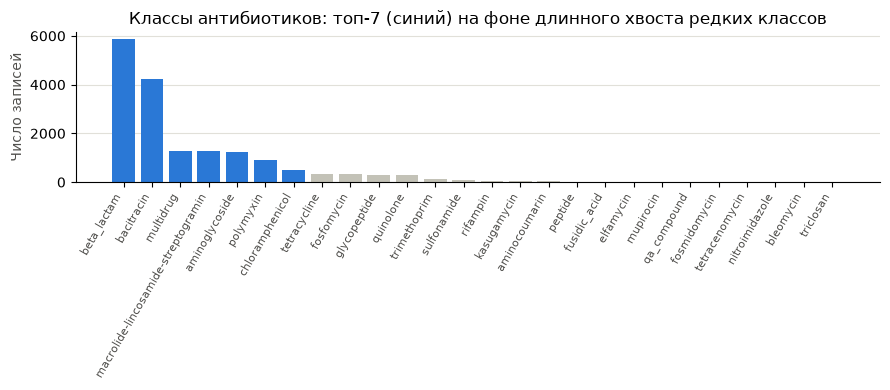

Всего классов: 26, top-7 обеспечивают покрытие 15267 из 17000 записей (90%)
Внутри top-7 также присутствует дисбаланс: beta_lactam (5853) против chloramphenicol (483) — отсюда stratify при разбиении


In [6]:
vc_all = df['antibiotic_class'].value_counts()
top4_classes = list(vc_all.index[:7])
bar_colors = ['#2a78d6' if c in top4_classes else '#c3c2b7' for c in vc_all.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(vc_all)), vc_all.values, color=bar_colors)
ax.set_xticks(range(len(vc_all)))
ax.set_xticklabels(vc_all.index, rotation=60, ha='right', fontsize=8, color='#52514e')
ax.set_ylabel('Число записей', color='#52514e')
ax.set_title('Классы антибиотиков: топ-7 (синий) на фоне длинного хвоста редких классов')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

covered = vc_all.iloc[:7].sum()
print(f"Всего классов: {len(vc_all)}, top-7 обеспечивают покрытие {covered} из {vc_all.sum()} записей ({covered / vc_all.sum():.0%})")
print(f"Внутри top-7 также присутствует дисбаланс: {vc_all.index[0]} ({vc_all.iloc[0]}) против {vc_all.index[6]} ({vc_all.iloc[6]}) — отсюда stratify при разбиении")

**Длина последовательностей.** Порог отсечения в 20 аминокислот отмечен пунктиром. Гистограмма показывает, где он находится относительно основного распределения.

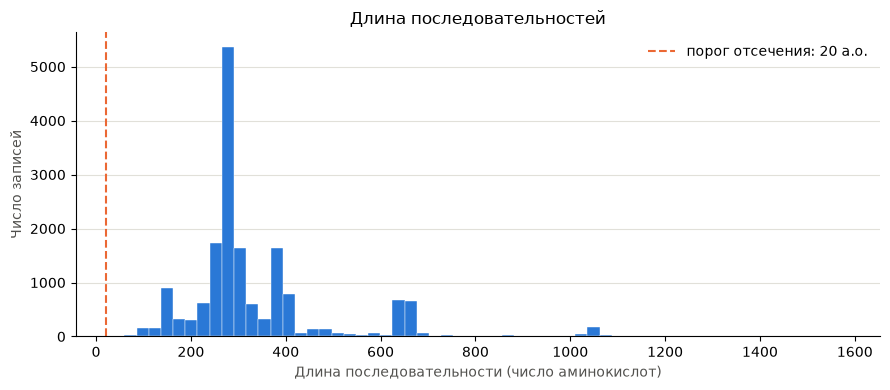

Минимальная длина в датасете: 34 а.о., короче порога — 0 записей
На данный момент порог не отсекает ни одной записи из данных, однако защитит от случайных фрагментов при изменении состава датасета в будущем


In [7]:
lengths = df['sequence'].str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=60, color='#2a78d6', edgecolor='white', linewidth=0.3)
ax.axvline(20, color='#eb6834', linestyle='--', linewidth=1.5, label='порог отсечения: 20 а.о.')
ax.set_xlabel('Длина последовательности (число аминокислот)', color='#52514e')
ax.set_ylabel('Число записей', color='#52514e')
ax.set_title('Длина последовательностей')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

short = (lengths < 20).sum()
print(f"Минимальная длина в датасете: {lengths.min()} а.о., короче порога — {short} записей")
print("На данный момент порог не отсекает ни одной записи из данных, однако защитит от случайных фрагментов при изменении состава датасета в будущем")

**Нестандартные аминокислоты и дубликаты.** Слева — какие нестандартные символы встречаются в последовательностях и как часто. Справа — сколько записей являются дубликатами уже присутствующих в датасете последовательностей.

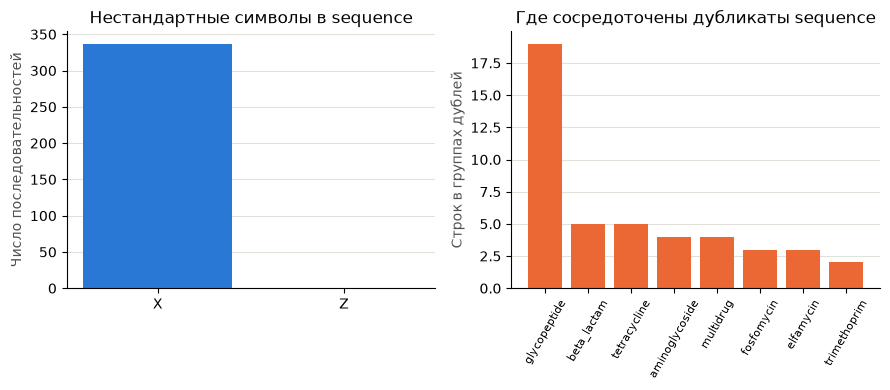

Нестандартные символы: {'X': 337, 'Z': 1}. Почти всё из них - X, стандартное обозначение 'неопределённого остатка' (обычно возникает из-за низкого качества секвенирования). Встречается редко (111 из 17000 последовательностей)
Точных дубликатов по sequence: 24 записей (48 строк входят в группы дублей). Чаще всего наблюдаются — у glycopeptide (19 строк). Убираем дубликаты перед split, чтобы не допустить утечку даннных из train в test.


In [8]:
import re
from collections import Counter

standard_aa = 'RHKDESTNQCGPAILMFWYV'
nonstd_mask = ~df['sequence'].str.contains(f'^[{standard_aa}]+$')
nonstd_chars = Counter()
for seq in df.loc[nonstd_mask, 'sequence']:
    nonstd_chars.update(re.sub(f'[{standard_aa}]', '', seq))

dup_rows = df[df.duplicated(subset='sequence', keep=False)]
dup_extra = df.duplicated(subset='sequence').sum()
dup_by_class = dup_rows['antibiotic_class'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(list(nonstd_chars.keys()), list(nonstd_chars.values()), color='#2a78d6')
axes[0].set_title('Нестандартные символы в sequence')
axes[0].set_ylabel('Число последовательностей', color='#52514e')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', color='#e1e0d9', linewidth=0.8)
axes[0].set_axisbelow(True)

axes[1].bar(dup_by_class.index, dup_by_class.values, color='#eb6834')
axes[1].set_title('Где сосредоточены дубликаты sequence')
axes[1].set_ylabel('Строк в группах дублей', color='#52514e')
axes[1].tick_params(axis='x', rotation=60, labelsize=8)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', color='#e1e0d9', linewidth=0.8)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"Нестандартные символы: {dict(nonstd_chars)}. Почти всё из них - X, стандартное обозначение "
      f"'неопределённого остатка' (обычно возникает из-за низкого качества секвенирования). Встречается редко "
      f"({nonstd_mask.sum()} из {len(df)} последовательностей)")
print(f"Точных дубликатов по sequence: {dup_extra} записей ({len(dup_rows)} строк входят в группы дублей). "
      f"Чаще всего наблюдаются — у {dup_by_class.index[0]} ({dup_by_class.iloc[0]} строк). "
      f"Убираем дубликаты перед split, чтобы не допустить утечку даннных из train в test.")

**Аминокислотный состав по классам.** Поскольку признаки модели — это частоты аминокислот, полезно посмотреть, отличается ли состав между классами уже на этом этапе. Сравним доли каждой аминокислоты в последовательностях top-7 классов.

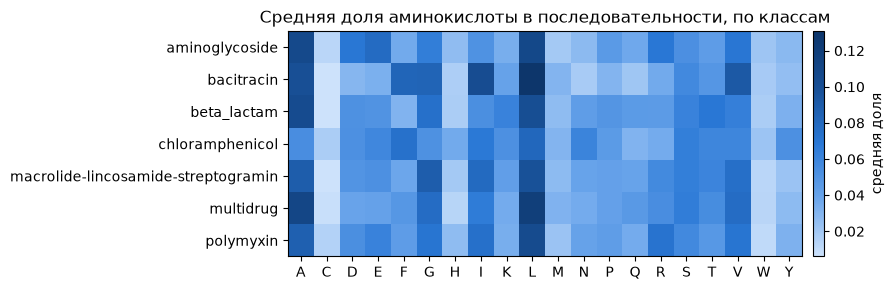

Сильнее всего различается по классам доля A (разброс 5.7%) и F (разброс 5.2%) — то есть в составе аминокислот уже есть сигнал для классификации, на который, например TF-IDF по отдельным аминокислотам сможет опереться.


In [9]:
from matplotlib.colors import LinearSegmentedColormap

blues = LinearSegmentedColormap.from_list(
    'blues_seq', ['#cde2fb', '#6da7ec', '#2a78d6', '#184f95', '#0d366b']
)

top4_df = df[df['antibiotic_class'].isin(top4_classes)]
aa_letters = list('ACDEFGHIKLMNPQRSTVWY')

def aa_frequencies(seq):
    counts = Counter(seq)
    length = len(seq)
    return [counts.get(aa, 0) / length for aa in aa_letters]

freq_matrix = pd.DataFrame(
    top4_df['sequence'].apply(aa_frequencies).tolist(),
    columns=aa_letters,
    index=top4_df.index,
)
class_profile = freq_matrix.groupby(top4_df['antibiotic_class']).mean()

fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(class_profile.values, cmap=blues, aspect='auto')
ax.set_xticks(range(len(aa_letters)))
ax.set_xticklabels(aa_letters)
ax.set_yticks(range(len(class_profile.index)))
ax.set_yticklabels(class_profile.index)
ax.set_title('Средняя доля аминокислоты в последовательности, по классам')
fig.colorbar(im, ax=ax, label='средняя доля', fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

spread = (class_profile.max() - class_profile.min()).sort_values(ascending=False)
print(f"Сильнее всего различается по классам доля {spread.index[0]} (разброс {spread.iloc[0]:.1%}) "
      f"и {spread.index[1]} (разброс {spread.iloc[1]:.1%}) — то есть в составе аминокислот уже есть "
      f"сигнал для классификации, на который, например TF-IDF по отдельным аминокислотам сможет опереться.")

## 4. Отбор классов и очистка последовательностей

* Ограничим задачу определением 7 наиболее представленных классов. 
* Исключим последовательности с нестандартным аминокислотами (иначе велик риск начать считать отсутствие аминокислоты признаком какого-либо класса, эту проблему нужно было бы дополнительно решать)
* Исключим слишком короткие последовательности (< 20 остатков) — такая длина нетипична для полноценного белка и, вероятнее всего, указывает на фрагмент.

In [10]:
n = 7
vc = df['antibiotic_class'].value_counts()
classes = list(vc[:n].index)
df = df[df['antibiotic_class'].isin(classes)]

In [11]:
AA_mask = df['sequence'].str.contains('^[RHKDESTNQCGPAILMFWYV]+$')
df = df.loc[AA_mask]
'{} rows were removed'.format((AA_mask == False).sum())

'105 rows were removed'

In [12]:
AA_length_mask = df["sequence"].str.len() >= 20
df = df.loc[AA_length_mask]

## 5. Дедупликация и разбиение на train/test

* В данных есть повторяющиеся строки: одна и та же последовательность с одним и тем же классом встречается несколько раз. Если такая последовательность попадёт и в train, и в test, произойдет leak и на тесте модель будет угадывать уже увиденный пример, что приведет к завышению метрик — поэтому перед разбиением необходимо провести дедупликацию.

* Разбиваем данные с помощью `stratify=df['antibiotic_class']`, поскольку классы сильно не сбалансированы: без стратификации доли классов в train и test могут случайно разойтись. `random_state` фиксируем для воспроизводимости разбиения.

In [13]:
classes

['beta_lactam',
 'bacitracin',
 'multidrug',
 'macrolide-lincosamide-streptogramin',
 'aminoglycoside',
 'polymyxin',
 'chloramphenicol']

In [14]:
df = df.drop_duplicates(subset='sequence')

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['antibiotic_class'],
)

Кодируем классы целыми числами.

In [15]:
label_columns = sorted(df['antibiotic_class'].unique())
class_to_idx = {name: idx for idx, name in enumerate(label_columns)}

train_labels = train_df['antibiotic_class'].map(class_to_idx).values
test_labels = test_df['antibiotic_class'].map(class_to_idx).values

In [16]:
label_columns

['aminoglycoside',
 'bacitracin',
 'beta_lactam',
 'chloramphenicol',
 'macrolide-lincosamide-streptogramin',
 'multidrug',
 'polymyxin']

## 6. Токенизация

TfidfVectorizer принимает текст и токенизатор. Ниже — таблица кодов аминокислот и функция, которая превращает последовательность в список целочисленных токенов (по одному на аминокислоту).

In [17]:
codes = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
         'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
codes = list(map(lambda x: x.lower(), codes))

def create_dict(codes):
  char_dict = {}
  for index, val in enumerate(codes):
    char_dict[val] = index+1

  return char_dict

char_dict = create_dict(codes)

print(char_dict)
print("Dict Length:", len(char_dict))

{'a': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'p': 13, 'q': 14, 'r': 15, 's': 16, 't': 17, 'v': 18, 'w': 19, 'y': 20}
Dict Length: 20


In [18]:
def integer_encoding(data):
  """
  - Переводит последовательность кодов в целочисленные значения.
  - Узнает 20 стандартных аминокислот, остальные — как 0.
  """

  row_encode = []
  for code in data:
    row_encode.append(char_dict.get(code, 0))

  return row_encode

In [19]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=integer_encoding)
X_train = tfidf_vectorizer.fit_transform(train_df['sequence']).toarray()
X_test = tfidf_vectorizer.transform(test_df['sequence']).toarray()

/home/v/.venvs/jupyter-experiments-env/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [20]:
X_train.shape

(12124, 20)

## 7. Upsampling + DataLoader

In [21]:
class TextDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # признаки
        self.y = torch.tensor(y, dtype=torch.long)  # индексы классов для CrossEntropyLoss

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, index):
        return self.X[index], self.y[index]  # Возвращаем образец и метку

**Upsampling.** Дублируем для train случайные примеры редких классов до размера самого частого класса. Test не трогаем — он должен отражать исходное распределение классов, иначе метрика перестанет быть честной.

In [22]:
from collections import Counter

idx_to_class = dict(enumerate(label_columns))
before_counts = Counter(train_labels)
print('Train до upsampling:', {idx_to_class[k]: v for k, v in sorted(before_counts.items())})

max_size = max(before_counts.values())
rng = np.random.default_rng(42)

resampled_idx = []
for cls, size in before_counts.items():
    cls_idx = np.where(train_labels == cls)[0]
    extra_idx = rng.choice(cls_idx, size=max_size - size, replace=True)
    resampled_idx.append(np.concatenate([cls_idx, extra_idx]))
resampled_idx = np.concatenate(resampled_idx)

X_train = X_train[resampled_idx]
train_labels = train_labels[resampled_idx]

print('Train после upsampling:', {idx_to_class[k]: v for k, v in sorted(Counter(train_labels).items())})
print('X_train.shape:', X_train.shape)

Train до upsampling: {'aminoglycoside': 992, 'bacitracin': 3372, 'beta_lactam': 4613, 'chloramphenicol': 386, 'macrolide-lincosamide-streptogramin': 1007, 'multidrug': 1024, 'polymyxin': 730}
Train после upsampling: {'aminoglycoside': 4613, 'bacitracin': 4613, 'beta_lactam': 4613, 'chloramphenicol': 4613, 'macrolide-lincosamide-streptogramin': 4613, 'multidrug': 4613, 'polymyxin': 4613}
X_train.shape: (32291, 20)


In [23]:
# Подготовка данных
train_dataset = TextDataset(X_train, train_labels)
test_dataset = TextDataset(X_test, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 8. Модель: MLP

Признаки по Baseline — это вектор частот аминокислот фиксированной длины. Для работы с ними подойдет полносвязная сеть (MLP). Наследуем её сразу от `BaseEstimator`/`ClassifierMixin` вместе с `nn.Module`, чтобы модель сама умела `fit`/`predict`/`predict_proba` и её можно было положить в `sklearn.Pipeline` без отдельной обёртки.

In [24]:
class MLPModel(nn.Module, BaseEstimator, ClassifierMixin):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.linear1 = nn.Linear(input_dim, hidden_dim)  # Первый линейный слой
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, hidden_dim // 8)  # Второй линейный слой
        self.linear3 = nn.Linear(hidden_dim // 8, output_dim)  # Выходной линейный слой

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)
        return x

    def fit(self, X, y=None):
        return self  # обучаем отдельным циклом ниже, а не через fit()

    def __sklearn_is_fitted__(self):
        return True

    def predict_proba(self, X):
        if hasattr(X, 'toarray'):  # TfidfVectorizer отдаёт разреженную матрицу
            X = X.toarray()
        device = next(self.parameters()).device
        self.eval()
        with torch.no_grad():
            logits = self(torch.tensor(X, dtype=torch.float32).to(device))
        return torch.nn.functional.softmax(logits, dim=1).cpu().numpy()

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

In [25]:
# Параметры модели
input_dim = X_train.shape[1]  # Размерность входа (количество признаков TF-IDF)
hidden_dim = 256
output_dim = len(label_columns)  # Количество классов антибиотиков

# Создание модели
model = MLPModel(input_dim, hidden_dim, output_dim).to(device)

In [26]:
output_dim

7

## 9. Обучение

Обучать будем минимизируя `CrossEntropyLoss` - стандарт для многоклассовой классификации.

In [27]:
# Обучение модели
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20

In [28]:
for epoch in range(num_epochs):

    model.train()

    for texts, labels in train_loader:

        texts, labels = texts.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/20], Loss: 1.0841
Epoch [2/20], Loss: 0.3369
Epoch [3/20], Loss: 0.2599
Epoch [4/20], Loss: 0.1541
Epoch [5/20], Loss: 0.0346
Epoch [6/20], Loss: 0.0009
Epoch [7/20], Loss: 0.3048
Epoch [8/20], Loss: 0.0770
Epoch [9/20], Loss: 0.0802
Epoch [10/20], Loss: 0.0522
Epoch [11/20], Loss: 0.0221
Epoch [12/20], Loss: 0.0327
Epoch [13/20], Loss: 0.0814
Epoch [14/20], Loss: 0.2414
Epoch [15/20], Loss: 0.0964
Epoch [16/20], Loss: 0.0180
Epoch [17/20], Loss: 0.3313
Epoch [18/20], Loss: 0.0265
Epoch [19/20], Loss: 0.0112
Epoch [20/20], Loss: 0.0028


Наблюдаем overall снижение loss на train, скачки, вероятно, связаны с тем, какие классы попали в батчи.

## 10. Оценка на test

In [29]:
model.eval()

y_true, y_pred = [], []

# Отключаем расчёт градиентовЫ
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)  # логиты классов
        predictions = torch.argmax(outputs, dim=1)  # индекс класса с максимальным логитом

        y_true.extend(target.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

In [30]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Macro F1 - среднее по всем классам с равным весом, без поправки на дисбаланс классов
f1 = f1_score(y_true, y_pred, average='macro')
print(f'F1 Score (macro): {f1:.4f}')

# F1 и другие метрики отдельно по каждому классу
report = classification_report(y_true, y_pred, target_names=label_columns, zero_division=0)
print("Classification Report:")
print(report)

F1 Score (macro): 0.9485
Classification Report:
                                     precision    recall  f1-score   support

                     aminoglycoside       0.86      0.98      0.92       248
                         bacitracin       0.99      0.99      0.99       843
                        beta_lactam       1.00      0.96      0.98      1154
                    chloramphenicol       0.96      0.96      0.96        96
macrolide-lincosamide-streptogramin       0.90      0.95      0.92       252
                          multidrug       0.91      0.91      0.91       256
                          polymyxin       0.97      0.96      0.96       183

                           accuracy                           0.96      3032
                          macro avg       0.94      0.96      0.95      3032
                       weighted avg       0.97      0.96      0.97      3032



## 11. Joblib-бандл: pipeline + metadata

Сохраняем препроцессинг и модель одним артефактом: `pipeline` — TF-IDF и MLP в одном `sklearn.Pipeline`, `metadata` — версия, порядок фичей TF-IDF и порог уверенности.

Порог возьмем из фактического распределение уверенности модели на test отдельно для верных и ошибочных предсказаний.

In [31]:
from sklearn.pipeline import Pipeline
import joblib

inference_pipeline = Pipeline([
    ('tfidf', tfidf_vectorizer),
    ('model', model),
])

test_proba = inference_pipeline.predict_proba(test_df['sequence'].tolist())
test_conf = test_proba.max(axis=1)
is_correct = test_proba.argmax(axis=1) == test_labels

print(f"Уверенность на верных предсказаниях: медиана {np.median(test_conf[is_correct]):.2f}, "
      f"5-й перцентиль {np.percentile(test_conf[is_correct], 5):.2f}")
print(f"Уверенность на ошибках: медиана {np.median(test_conf[~is_correct]):.2f}, "
      f"95-й перцентиль {np.percentile(test_conf[~is_correct], 95):.2f}")

threshold = round(float(np.percentile(test_conf[is_correct], 5)), 2)
print(f"Порог: {threshold} — ниже него верные предсказания на test встречаются лишь в ~5% случаев")

metadata = {
    'version': '1.0.0',
    'feature_order': tfidf_vectorizer.get_feature_names_out().tolist(),
    'threshold': threshold,
}

Уверенность на верных предсказаниях: медиана 1.00, 5-й перцентиль 0.86
Уверенность на ошибках: медиана 0.61, 95-й перцентиль 0.98
Порог: 0.86 — ниже него верные предсказания на test встречаются лишь в ~5% случаев


In [33]:

joblib.dump({'pipeline': inference_pipeline, 'metadata': metadata}, '../../artifact/amr_prediction_bundle.joblib')

['../../artifact/amr_prediction_bundle.joblib']

## 12. Примеры для проверки инференса

Берём из test несколько последовательностей на класс и сохраняем в отдельный файл рядом с бандлом — чтобы на инференсе можно было проверить.

In [34]:
sample_rows = [
    test_df[test_df['antibiotic_class'] == cls].sample(3, random_state=42)
    for cls in label_columns
]
sample_sequences = pd.concat(sample_rows)[['sequence', 'antibiotic_class']].reset_index(drop=True)
sample_sequences.to_csv('../../examples/sample_test_sequences.csv', index=False)
sample_sequences

,sequence,antibiotic_class
0,MTNCNDSVTLRLMTEHDLAMLYGWLNRSHIVEWWGGEEARPTLADV...,aminoglycoside
1,MSEPYLSRWRLRRDGPALRTPHARLWPVLTAAGEPAMLKISSETEE...,aminoglycoside
2,MTIEISNQLSEVLSVIERHLESTLLAVHLYGSAVDGGLEPYSDIDL...,aminoglycoside
3,MSDWLAAIILGLVEGLTEFIPVSSTGHMLLLGHFMGFQSSGKTFEI...,bacitracin
4,MAETSTIVAALLGLLEGLTEFIPVSSTGHLLLAGHFLDFESAGKTF...,bacitracin
5,MAEMLKSLVLGIVQGITEWLPISSTGHLLLLDEVLHLRLGENAKEL...,bacitracin
6,MTKMNRLAAALIAALILPTAHAAQQQDIDAVIQPLMKKYGVPGMAI...,beta_lactam
7,MNHSLQKFLFSALLISSGSCVAATDLRTVVDAGVKPLMQQQGIPGL...,beta_lactam
8,MNIKALLLITSAIFISACSPYIVTANPNHSASKSDEKGEKIKNLFN...,beta_lactam
9,MNFFTSPFSGSPLDQQVTNPNIIVGKHSYYSGYYHGHSFDDCARYL...,chloramphenicol
